# Taller computacional

Se tiene el siguente modelo ODE que representa la operación de un bioreactor en modo fed-batch.

$$ \frac{dX}{dt} = \mu\cdot X $$
$$ \frac{dS}{dt} = -\sigma\cdot X + u\cdot c_{s,F} $$
$$ \frac{dP}{dt} = \pi\cdot X $$
$$ \frac{dV}{dt} = u $$

Donde:
- $X$ es la biomasa (g)
- $S$ es el sustrato (g)
- $P$ es el producto lisina (g)
- $V$ es el volumen en el fermentador (L)
- $u$ es la tasa volumétrica del flujo de alimentación.
- $c_{s,F}$ es la concentración de sustrato en la alimentación (g/L) = 2.8.
- $\mu$ es la tasa de crecimiento (1/h)
- $\sigma$ es la tasa de consumo de sustrato (g S/gX h)
- $\pi$ es la tasa de producción (g P/g X h)


Las ecuaciones constitutivas del modelo son:

- $\mu = 0.125\cdot c_s$
- $c_s = \frac{S}{V}$ es la concentración del sustrato
- $\sigma = \frac{\mu}{0.135}$
- $\pi = -384\cdot \mu^2 + 134\cdot \mu$

Las condiciones iniciales del problema son:
- $X(0) = 0.1 g$
- $S(0) = 14 g$
- $P(0) = 0 g$
- $V(0) = 5 L$

In [2]:
# importar las librerías
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import Bounds, minimize
import matplotlib.pyplot as plt

## 1 - Construir el modelo

Elabore y codifique el modelo ODE en la función `fed_batch`

In [4]:
def fed_batch(t,x,u,Csf):
    """
    Función que calcula el ODEs del modelo fed-batch
    
    Entrada:
    t (array): tiempo de integración
    x (array): vector variables de estados (dim = 4)
    u (array): vector variable de control (dim = 1)
    Csf (array o float): parámetro del modelo (escalar)
    
    Salida:
    dxdt (array): vector con las derivadas de las ODEs (dim = 4)
    """    
    
    # consejo: declare las variables con la nomenclatura de las ecuaciones
    # Unpack state variables
    X, S, P, V = x  # Biomass (g), Substrate (g), Product (g), Volume (L)
    
    # escriba acá las ecuaciones constitutivas 
    # Constitutive equations
    cs = S / V                       # Substrate concentration in reactor (g/L)
    mu = 0.125 * cs                  # Growth rate (1/h)
    sigma = mu / 0.135               # Substrate consumption rate (g S / g X / h)
    pi = -384 * mu**2 + 134 * mu     # Product formation rate (g P / g X / h)
    
    # escriba acá las ecuaciones diferenciales    
    # Differential equations
    dXdt = mu * X                    # Biomass growth
    dSdt = -sigma * X + u * Csf      # Substrate consumption
    dPdt = pi * X                    # Product formation
    dVdt = u                         # Volume change

    # Pack derivatives into a vector
    dxdt = [dXdt, dSdt, dPdt, dVdt]
    
    return dxdt

## 2 - Integración del ODE

Utilice las funciones `Euler_method` y `RK4_method` vistas en clases para para integrar el ODE. Verifique que los solvers funcionan adecuadamente. Para ello, compare cada uno de estos con un método stiff usando la función `solve_ivp` de scipy. Revise la documentación de `solve_ivp` para escoger el `method` que resuelva ode stiff.

Para simulación utilice un valor constante de $u=0.5\hspace{0.1cm}L/h$ y $t_f=40 \hspace{0.1cm} h$ 

**Justifique**
- Es un problema stiff
- En caso de que no lo sea. Cual es el número de pasos $(n)$ mínimo que requiere `Euler_method` y `RK4_method` para que la integración se la correcta.

**Nota**: Para las funciones `Euler_method` y `RK4_method` debe usar un vector $u$ contanste de dimensión $n+1$. En el caso de la función `solve_ivp` debe usar un array o scalar con el mismo valor.

In [5]:
def Euler_method(f, t0, tf, x0, n, u, p):
    """
    Método de Euler explicito para integrar ODE.
    
    Entrada:
    f (function): función de python con el sistema ODE
    t0 (float): valor inicial de integración
    tf (float): valor del tiempo final de integración
    x0 (array): vector condiciones inicales (m)
    n (float): número de pasos o elementos finitos en el tiempo
    u (array): vector variable manipulada (n + 1)
    p (array): parámetros del modelo
    
    Salida:
    t (array): vector tiempo de integración (n + 1)
    x (array): vector de estados integrados (n + 1, m)
    """    
    h = tf/n # se calcula el tamaño del paso
    t = np.zeros(n+1)
    x = np.array((n+1)*[x0])
    t[0] = t0
    x[0] = x0
    
    for k in range(n):
        x[k+1] = x[k]+h*f(t[k],x[k],u[k],p)
        t[k+1] = t[k]+h
        
    return t,x

In [6]:
def RK4_method(f, t0, tf, x0, n, u, p):
    """
    Método Runge-Kutta explicito de 4to orden para integrar ODE.
    
    Entrada:
    f (function): función de python con el sistema ODE
    t0 (float): valor inicial de integración
    tf (float): valor del tiempo final de integración
    x0 (array): vector condiciones inicales (m)
    n (float): número de pasos o elementos finitos en el tiempo
    u (array): vector variable manipulada (n + 1)
    p (array): parámetros del modelo
    
    Salida:
    t (array): vector tiempo de integración (n + 1)
    x (array): vector de estados integrados (n + 1, m)
    """  
    h = tf/n
    t = np.zeros(n+1)
    x = np.array((n+1)*[x0])
    t[0] = t0
    x[0] = x0
    
    for k in range(n):
        
        k1 = f(t[k],x[k],u[k],p)
        k2 = f(t[k]+h/2,x[k]+(h/2)*k1,u[k],p)
        k3 = f(t[k]+h/2,x[k]+(h/2)*k2,u[k],p)
        k4 = f(t[k]+h,x[k]+h*k3,u[k],p)
        x[k+1] = x[k]+(h/6)*(k1+2*k2+2*k3+k4)
        t[k+1] = t[k]+h
                
    return t,x

In [7]:
# definición los parámetros de las funciones de integración
Csf =  2.8

In [8]:
# integración Euler y RK4
t1, x1 = Euler_method(fed_batch, 0, tf, x0, n, u, Csf)
t2, x2 = RK4_method(fed_batch, 0 , tf, x0, n, u, Csf)

NameError: name 'tf' is not defined

In [7]:
# integración con scipy
tspan = (0, tf)
sol = solve_ivp(fed_batch, tspan, x0, method = 'BDF', args=(u0, Csf))
t3 = sol.t
x3 = sol.y.T

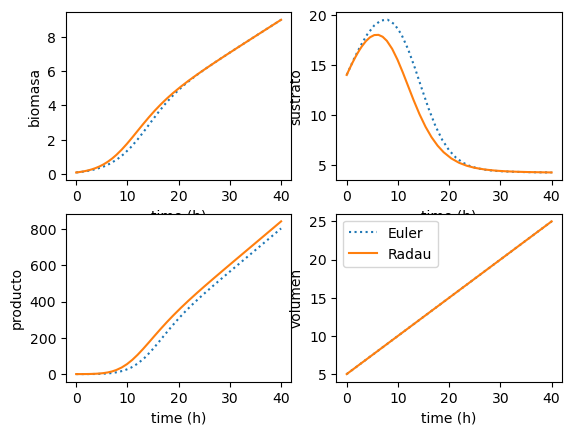

In [8]:
# Euler vs Radau
names = ['biomasa', 'sustrato', 'producto', 'volumen']
plt.figure()
for i in range(len(x0)):
    plt.subplot(2,2,i+1)
    plt.plot(t1,x1[:,i], ':')
    plt.plot(t3,x3[:,i])
    plt.xlabel('time (h)')
    plt.ylabel(names[i])
plt.legend(['Euler', 'Radau'])

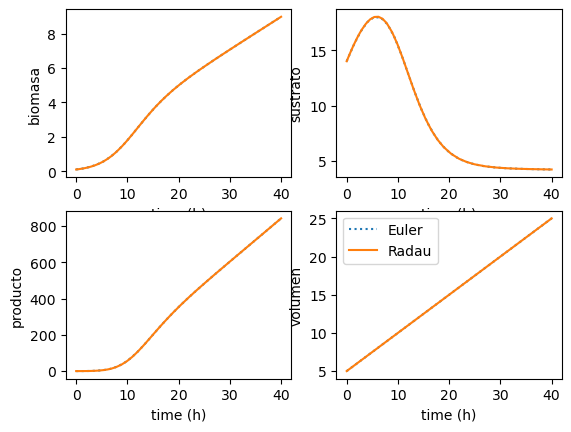

In [9]:
# RK4 vs Radau
names = ['biomasa', 'sustrato', 'producto', 'volumen']
plt.figure()
for i in range(len(x0)):
    plt.subplot(2,2,i+1)
    plt.plot(t2,x2[:,i], ':')
    plt.plot(t3,x3[:,i])
    plt.xlabel('time (h)')
    plt.ylabel(names[i])
plt.legend(['Euler', 'Radau'])

## 3 - Optimización

Se requiere optimizar el proceso de fermentación tomando en cuenta como variables de decisión la tasa volumétrica del flujo de alimentación en el tiempo de la forma $ u = [u_1, u_2, ..., u_n]$ y el tiempo final $t_f$ de la reacción. La función objetivo que se requiere optimizar es la siguiente:

$$ min \hspace{0.5cm} J(u_i,t_f) = (1-w)\cdot J_1 + w\cdot J_2 $$

Donde:
- $J_1 = -\frac{P(t_f)}{t_f}$
- $J_2 = -\frac{P(t_f)}{(V(t_f)-V(t_0))\cdot c_{s,F}}$

$J_1$ es la razón entre el producto final obtenido y el tiempo final del proceso que mide la **productividad** del proceso.

$J_2$ es la razón entre el producto final y la cantidad total de sustrato suministrado que mide el **rendimiento** del proceso.

El problema esta sujeto a las siguientes restricciones:

$$ 5 \hspace{0.1cm}L \leq V(t_i) \leq 20 \hspace{0.1cm}L \tag{1}$$
$$ 0 \hspace{0.1cm}L/h \leq u_i \leq 2 \hspace{0.1cm}L/h $$
$$ 20 \hspace{0.1cm}h \leq t_f \leq 40 \hspace{0.1cm}h $$
$$ (V(t_f)-V(t_0))\cdot c_{s,F} \geq 20 g \tag{2}$$

### 3.1 Funcion objetivo

Elabore y codifique la función objetivo $J(u_i,t_f)$ en la función de python 
`cost_function` 

Programe el vector de variables de decisión tiene el siguente orden:

$$ dv = [u_1, u_2, ..., u_n, t_f] $$

Donde:
- $u_1, u_2, ..., u_n$ son los valores de la dicretización de la variable manipulada $u$ que dependen del número de elementos finitos $n$
- $t_f$ es el valor del tiempo final del proceso

**Nota**: Utilice la función `RK4_method` para integrar el modelo.

In [15]:
# %% objetive function (multi-objetive)
def cost_function(dv, n, x0, Csf, w):
    """
    Calcula la función objetivo J(ui,tf)
    
    Entrada:
    dv (array): vector con las variables de decisión
    n (float): número de pasos o elementos finitos en el tiempo (escalar)
    x0 (array): vector condiciones inicales (dim = m)
    Csf (array o float): parámetro del modelo (escalar)
    w (array o float): peso de la función objetivo (escalar)
    
    Salida:
    J (float): valor de la función  objetivo (escalar)
    """
    
    # llame a la función que integra al sistem RK4_method
    # obtenga las expresiones de j1 y j2 
    # calcule J
  
    return J

### 3.2  Restriciones de desigualdad

Elabore y codifique las restricciones (1) y (2) en las funciones `restriccion_volumen` y `restriccion_sustrato`.

**Nota**: Las restricciones en scipy se escriben de la forma:

$$ g(x) \geq 0$$

In [16]:
def restriccion_volumen(dv, n , x0, Csf):
    """
    Calcula la restricción de volumen máximo en el reactor
    
    Entrada:
    dv (array): vector con las variables de decisión
    n (float): número de pasos o elementos finitos en el tiempo (escalar)
    x0 (array): vector condiciones inicales (dim = m)
    Csf (array o float): parámetro del modelo (escalar)   
    
    Salida:
    g (array): vector con las restricciones de volumen (dim = n + 1)
    """
    
    # llame a la función que integra al sistem RK4_method
    # obtenga las expresiones de las restricccioens g_i 
    # hint: use un bucle for
    
    return g

In [17]:
def restriccion_sustrato(dv, n, x0, Csf):
    """
    Calcula la restricción de cantidad de sustrato mínimo
    
    Entrada:
    dv (array): vector con las variables de decisión
    n (float): número de pasos o elementos finitos en el tiempo (escalar)
    x0 (array): vector condiciones inicales (dim = m)
    Csf (array o float): parámetro del modelo (escalar)   
    
    Salida:
    g (array): vector restricción (dim = 1 escalar)
    """
    # llame a la función que integra al sistem RK4_method
    # obtenga las expresión de las restricción g
        
    return g

### 3.3 Ejecución  optimización usando scipy.minimize optimize



In [18]:
# %% definición de inputs para función optimize
xL = [0.0]*(n+1) # limite inferior de u
tf_L = 20.0 # limite inferior de tf
xL = np.append(xL,20.0) # limite inferior de todas las variables de decision
xU = [2.0]*(n+1) # limite superior de u
tf_U = 40.0 # limite superior de tf
xU = np.append(xU,40.0) # limite superior de todas las variables de decision
bounds = Bounds(xL, xU) # se juntan los limites xL y xU en una sola variable
# configuración de las restriciones de desiguladad
con1 = {'type': 'ineq', 'fun': restriccion_volumen, 'args': (n, x0, Csf)}
con2 = {'type': 'ineq', 'fun': restriccion_sustrato, 'args': (n, x0, Csf)}
cons = ([con1,con2])
# valor inicial de iteración del algoritmo (initial guess)
u = np.random.uniform(low=0, high = 2, size=(n+1)) # valor aleatorio entre 0 y 2 para u
initial_guess = np.append(u,20.0) # se concatena valor inicial de iteraicón de tf
options = {'disp': True}
algorithm = 'SLSQP'

En la siguente celda usted ejecutará el problema de optimización. La función de costo que usted va a optimizar es multiobjetivo y se ha programado por el método de los pesos.

Ejecute la optimización para valores de $w = 0$, $w = 0.5$ y $w = 1.0$. Compare las trayectorias de $u$, el tiempo final $t_f$ obtenidas y sus respectivas funciones de costo $J_1$ y $J_2$.

In [21]:
w = 0.0

solution = minimize(cost_function,initial_guess, method='SLSQP',\
                    bounds=bounds, args = (n, x0, Csf, w),constraints=cons,
                    options=options)

u_opt = solution.x[:-1]   
tf_opt = solution.x[-1] 

t_opt, x_opt = RK4_method(fed_batch, 0, tf_opt, x0, n, u_opt, Csf)

j1 = -x_opt[-1,2]/tf_opt
j2 = -x_opt[-1,2]/((x_opt[-1,3]-x_opt[0,3])*Csf)
print(f' J1 = {j1} | J2 = {j2}')

Optimization terminated successfully    (Exit mode 0)
            Current function value: -23.788228542770067
            Iterations: 63
            Function evaluations: 2079
            Gradient evaluations: 63
 J1 = -23.788228542770067 | J2 = -12.649813582350575


Text(0.5, 0, '$t(h)$')

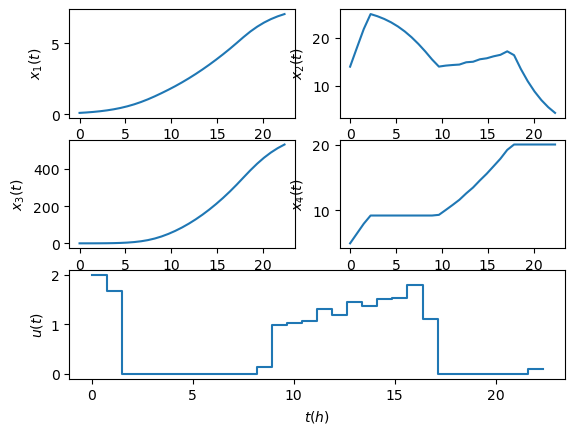

In [22]:
# %% grafico resultados optimización
plt.figure()
plt.subplot(3,2,1)
plt.plot(t_opt,x_opt[:,0])
plt.ylabel(r'$x_{1}(t)$')
plt.subplot(3,2,2)
plt.plot(t_opt,x_opt[:,1])
plt.ylabel(r'$x_{2}(t)$')
plt.subplot(3,2,3)
plt.plot(t_opt,x_opt[:,2])
plt.ylabel(r'$x_{3}(t)$')
plt.subplot(3,2,4)
plt.plot(t_opt,x_opt[:,3])
plt.ylabel(r'$x_{4}(t)$')
plt.subplot(3,2,(5,6))
plt.step(t_opt,u_opt)
plt.ylabel(r'$u(t)$')
plt.xlabel('$t(h)$')

## 4 - Optimización multi-objetivo usando NSGA-II

Obtenga el Frente de Pareto del problema de optimización usando el algoritmo NSGA-II.

Debe implementar el mismo problema en la clase `batch_moo_problem`, dentro del método (función) `_evaluate`.

**Nota**: Las restricciones en pymoo se escriben de la forma:

$$ g(x) \leq 0$$

Discuta si el frente de Pareto es Convexo o no Convexo.

**pista**: Trate de obtener el fente de pareto con el método de los pesos.

In [25]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

In [26]:
class batch_moo_problem(ElementwiseProblem):    

    def __init__(self):   
        
        n = 30 # número de elementos finitos
        xL = [0.0]*(n+1) # limite inferior de u
        tf_L = 20.0 # limite inferior de tf        
        xL = np.append(xL,20.0) # limite inferior de todas las variables de decision        
         
        xU = [2.0]*(n+1) # limite superior de u
        tf_U = 40.0 # limite superior de tf
        xU = np.append(xU,40.0) # limite superior de todas las variables de decision
        
        # se define las dimensiones del problema
        # debe completar
        # n_var: número de variables de decisión
        # n_obj: número de objetivos
        # n_constr: número de restricciones (volumen + sustrato)
        super().__init__(n_var = , n_obj = , n_constr=, xl = xL, xu = xU)
        
    def _evaluate(self, dv, out, *args, **kwargs):       
        
        # debe hacer acá el mismo código de la cost_function
        # debe también calcular acá las restriccion del sustrato y restriccion de volumen
        # 
           
            
        out["F"] = [j1, j2]
        out["G"] = [g]

En la siguente celda usted ejecutará el problema de optimización usando NSGA-II. 

In [27]:
# %% inicializar el algoritmo
problem = batch_moo_problem()
algorithm = NSGA2(pop_size=100, n_offsprings=20, eliminate_duplicates=True)
# ejecutar problema de optimización
res = minimize(problem, algorithm, ("n_gen", 200), verbose=True, seed = 42)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  1.089210E+01 |  1.305007E+02 |             - |             -
     2 |      120 |      1 |  8.8554561152 |  9.972263E+01 |             - |             -
     3 |      140 |      1 |  8.8554561152 |  8.039550E+01 |             - |             -
     4 |      160 |      1 |  3.1489034833 |  6.505115E+01 |             - |             -
     5 |      180 |      1 |  0.000000E+00 |  5.185224E+01 |             - |             -
     6 |      200 |      2 |  0.000000E+00 |  4.179113E+01 |  1.0000000000 |         ideal
     7 |      220 |      4 |  0.000000E+00 |  3.251440E+01 |  0.3163093921 |         ideal
     8 |      240 |      6 |  0.000000E+00 |  2.318919E+01 |  0.0367330207 |         ideal
     9 |      260 |      7 |  0.000000E+00 |  1.574295E+01 |  0.0455953629 |             f
    10 |      280 |      9 |  0.000000E+00 |  1.017505E+01 |  0.0101842559 |         ideal

### Gráfica del prente de pareto

Text(0, 0.5, '$J_{2}(x)$')

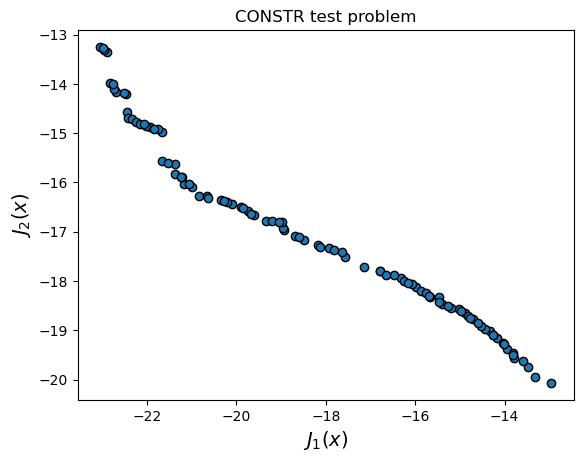

In [28]:
plt.figure()
plt.plot(res.F[:,0], res.F[:,1], 'o', markeredgecolor = 'black')
plt.title('CONSTR test problem')
plt.xlabel(r'$J_{1}(x)$', fontsize = 14)
plt.ylabel(r'$J_{2}(x)$', fontsize = 14)

### Grafica pareto set (variables de desición)

Text(0.5, 0, '$t(h)$')

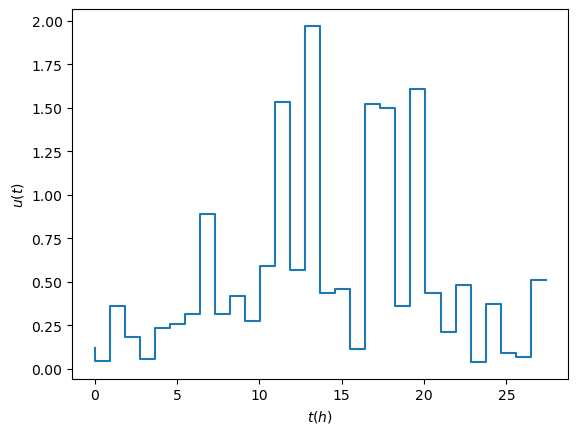

In [37]:
ID = 70 # elegir un número de la solución
tf = res.X[ID,-1]
t = np.linspace(0,tf,n+1)
plt.step(t, res.X[ID,:-1])
plt.ylabel(r'$u(t)$')
plt.xlabel('$t(h)$')